# Computer Vision - P1

### **Carefully read the following instructions before start coding.**

==============================================================================================
## Delivery

Up to **1 point out of 10** will be penalized if the following requirements are not fulfilled:

- Implemented code should be commented.

- The questions introduced in the exercises must be answered.

- Add title to the figures to explain what is displayed.

- Comments and answers need to be in **English**.

- The deliverable must be a file named **P1_Student1_Student2.zip** that includes:
    - The notebook P1_Student1_Student2.ipynb completed with the solutions to the exercises and their corresponding comments.

**Deadline (Campus Virtual): October, 8, 2024 23:00 h**

==============================================================================================

## Practicum 1: Basics on Image Processing and Manipulation
==============================================================================================

The main topics are:

1. Image loading, saving and creation

2. Color manipulation

In order to complete this practicum, we will work with the following concepts: image creation, data types, image manipulation.

==============================================================================================
### Packages loading

First we need to import the required Python packages for basic image manipulation.

Run the following code:

In [1]:
import numpy as np # useful for manipulating matrices
from skimage import io # useful for image loading and saving
from matplotlib import pyplot as plt # useful for plotting images on iPython or Jupyter Notebooks

Note that commands starting with the percentage sign (`%`) are special internal commands to ipython (as opposed to Python code to be run). In the case below, we set the matplotlib environment to display images results inline (i.e. the images will be shown **inside the
notebook**):

In [2]:
%matplotlib inline
# We did not have skimage installed, so we use pip to do so
%pip install scikit-image

Note: you may need to restart the kernel to use updated packages.


==============================================================================================

### 1.1 Image creation

Remember that [Numpy](https://docs.scipy.org/doc/numpy-1.13.0/reference/) allows us to define images of different kinds treating them as matrices.

The most common examples are:

* Binary: with values of 0 or 1, interpreted as black or white, respectively.
* Grayscale: with possible data types uint8, uint16, double, whose pixel values define their intensity.
* RGB Image: color images consisting of 3 matrices (usually called 'channels'), which contain intensity values for each color separately R (red), G (green) and B (blue).


a) Create and display a grayscale image that has 100 rows and 100 columns where each value should be of type unsigned integer with 8 bits.

In [3]:
i = np.zeros((100,100,3),dtype=np.uint8)

How many different values can each pixel have in this case?
$2^8=256$, because we are working with unsigned data of 8 bits.

b) Create and display a **RGB image** that has 100 rows and 100 columns where each value should be of type unsigned integer with 8 bits. Then, transform it to grayscale.:

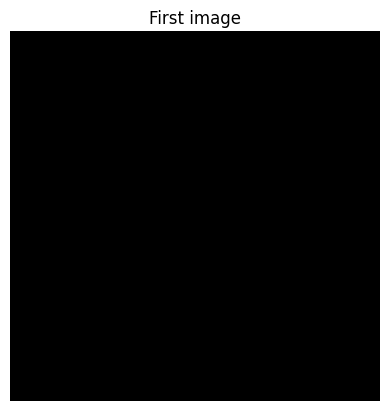

In [4]:
plt.imshow(i,cmap="gray")
plt.axis("off")
plt.title("First image")
plt.show()

c) Change the color of the pixels of the image in section **a)** in such a way that you produce the following image. You must use a plot with three subplots.

![./images_notebook/gray_grid.png](./images_notebook/gray_grid.png)

Visualize the image and print the values of its first row.

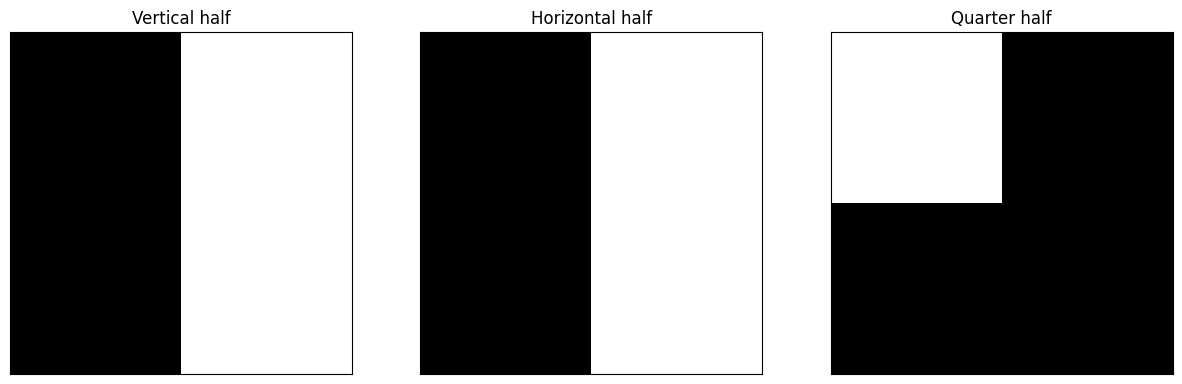

In [5]:
ig, axs = plt.subplots(nrows=1, ncols=3,figsize=(15,5))

ax = axs[0]
ii = np.copy(i)
ii[:,50:,:] = [255,255,255]
ax.imshow(ii)
ax.set_title('Vertical half')

ax = axs[1]
iii = np.copy(i)
iii[50:,:,:] = [255,255,255]
ax.imshow(ii)
ax.set_title('Horizontal half')

ax = axs[2]
iv = np.copy(i)
iv[:50,:50,:] = [255,255,255]
ax.imshow(iv)
ax.set_title('Quarter half')


plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()

d) Flip the third image to create a mirror ilusion. Show the resulting image while preseving the axis.

![./images_notebook/mirror.png](./images_notebook/mirror.png)

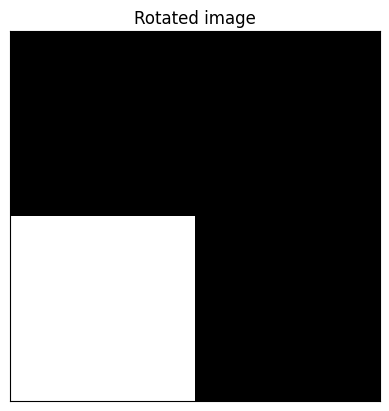

In [6]:
# We decided to use a proper method of numpy
v = np.rot90(iv)
plt.imshow(v)
plt.xticks([]); plt.yticks([]) # Off ticks
plt.title("Rotated image")
plt.show()

e) Use the above three images (from 1.c) to create the following image

![./images_notebook/color_grid.png](./images_notebook/color_grid.png)

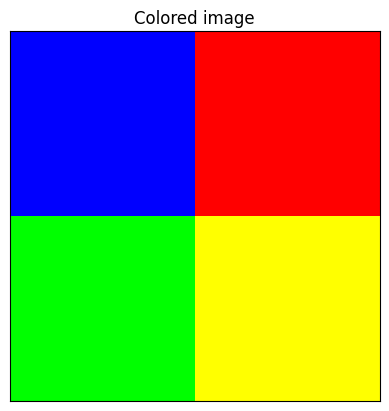

In [7]:
vi = np.copy(i)
vi[:50,:50,2] = 255
vi[:,50:,0] = 255
# Yellow is 
vi[50:,:,1] = 255
plt.imshow(vi)
plt.xticks([]); plt.yticks([]) # Off ticks
plt.title("Colored image")
plt.show()

### 1.2 Image saving and loading

a) Use the IO image package to save the previously generated image:

In [8]:
# Writing the image
io.imsave('images_notebook/colors.jpg',vi)

b) Load the saved image and visualize it. Print the dimensions, the value of pixel (10,10) and data type in order to check everything is correct

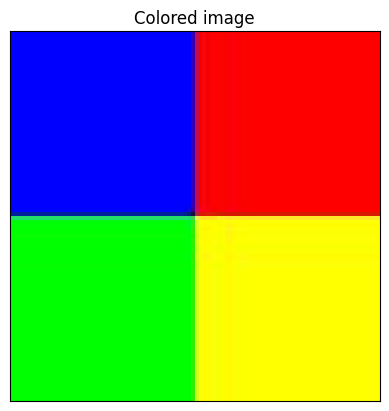

uint8
(100, 100, 3)
[  0   0 254]


In [9]:
# Loading the image
img = io.imread("images_notebook/colors.jpg")
plt.imshow(img)
plt.xticks([]); plt.yticks([]) # Off ticks
plt.title("Colored image")
plt.show()
print(img.dtype)
print(img.shape)
print(img[10,10])

### 1.3 Color image manipulation

a) Load and show the image `images_notebook/panda.jpg`, and check its dimensions and data type.

**Note:** Pictures may appear in the figure with pseudocolors. What commands to use in order to display them in **RGB** color and in **grayscale**?!

(800, 1200, 3)
uint8


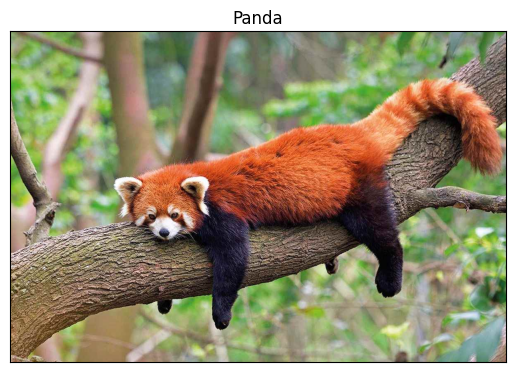

In [10]:
panda = io.imread("images_notebook/panda.jpg")
print(panda.shape) # It indicates RGB color
print(panda.dtype) # It indicates RGB color

# These commands may be used
plt.imshow(panda)
plt.xticks([]); plt.yticks([]) # Off ticks
plt.title("Panda")
plt.show()

b) Convert the previous image to grayscale, and **save it**.

Moreover, plot the two images (RGB & greyscale) in a single figure, and show details such as shape, dtype, max and min values.

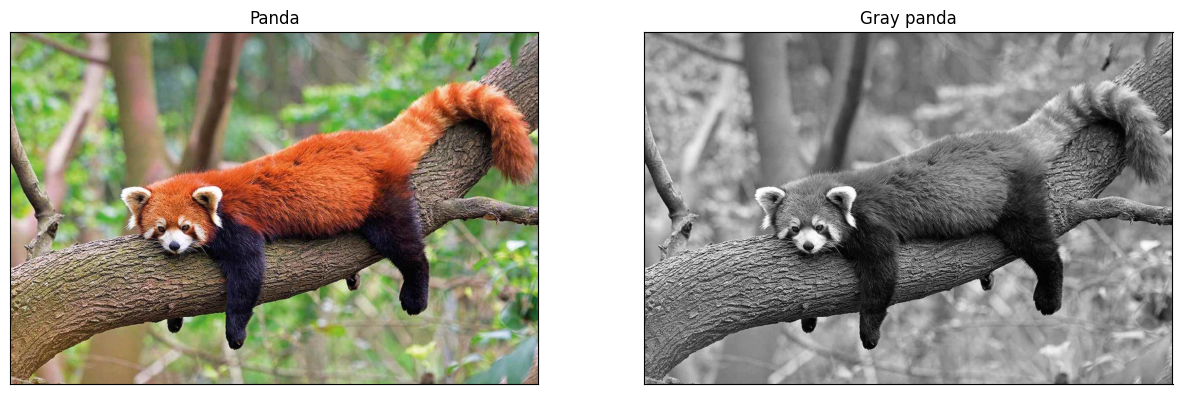

In [11]:
# In order to convert the previous image to grayscale, we need rgb2gray(img) (cf. tutorial_p1)
from skimage.color import rgb2gray
gray_panda = rgb2gray(panda)

ig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15,5))

ax = axs[0]
ax.imshow(panda)

ax.set_title('Panda')

ax = axs[1]
ax.imshow(gray_panda, cmap='gray')
ax.set_title('Gray panda')

plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()

In [12]:
from skimage import img_as_ubyte, img_as_uint, img_as_float
help(img_as_ubyte)

Help on function img_as_ubyte in module skimage.util.dtype:

img_as_ubyte(image, force_copy=False)
    Convert an image to 8-bit unsigned integer format.

    Parameters
    ----------
    image : ndarray
        Input image.
    force_copy : bool, optional
        Force a copy of the data, irrespective of its current dtype.

    Returns
    -------
    out : ndarray of ubyte (uint8)
        Output image.

    Notes
    -----
    Negative input values will be clipped.
    Positive values are scaled between 0 and 255.



In [13]:
print(f"NORMAL PANDA: SHAPE: {panda.shape}, TYPE: {panda.dtype}, MIN: {panda.min()}, MAX: {panda.max()}")
print(f"GRAY PANDA: SHAPE: {gray_panda.shape}, TYPE: {gray_panda.dtype}, MIN: {gray_panda.min()}, MAX: {gray_panda.max()}")

# Writing the image, keeping in mind that dtype is float64
uint8_panda = img_as_ubyte(gray_panda)
io.imsave('images_notebook/gray_panda.jpg', uint8_panda, cmap='gray')

NORMAL PANDA: SHAPE: (800, 1200, 3), TYPE: uint8, MIN: 0, MAX: 255
GRAY PANDA: SHAPE: (800, 1200), TYPE: float64, MIN: 0.0, MAX: 1.0


c) Compute the mean of the previous grayscale image and use a logical operation to obtain a boolean image. Pixels greather than the mean value must be shown as white. Display the binary image.

bool


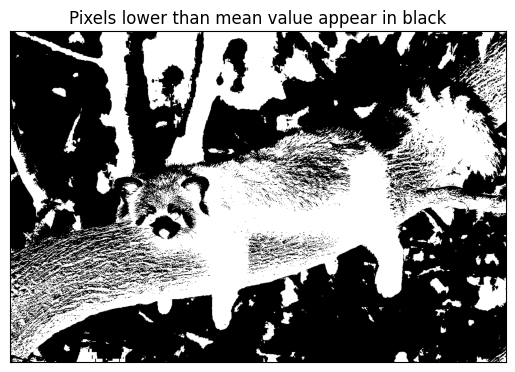

In [14]:
lower = gray_panda <= gray_panda.mean()
print(lower.dtype)
plt.imshow(lower, cmap='gray')
plt.xticks([]); plt.yticks([]) # Off ticks
plt.title("Pixels lower than mean value appear in black")
plt.show()

d) Visualize in the same figure all the three images: (1) the original image, (2) the gray image, and (3) the binarized image. Set the corresponding titles of the images and their descriptions

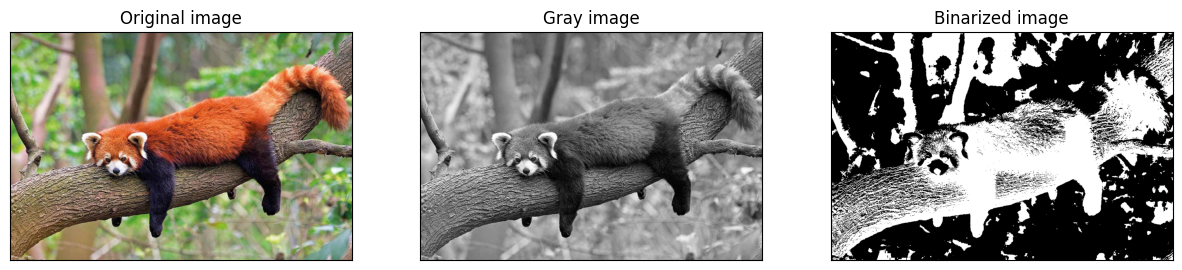

In [15]:
ig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15,5))

ax = axs[0]
ax.imshow(panda)
ax.set_title('Original image')

ax = axs[1]
ax.imshow(uint8_panda, cmap='gray')
ax.set_title('Gray image')

ax = axs[2]
ax.imshow(lower, cmap='gray')
ax.set_title('Binarized image')

plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()

### 1.4 Images manipulation

a) Create an RGB black image, 15% larger than the panda image. Afterwards, embed the dog image in the center. Show the framed image.

**Note:** Be carefull with the number of channels.

**Note:** Print the original image shape and the new image size to check if the sizes of the second one are 15% larger then the first one.


In [16]:
from skimage.transform import resize
# See https://scikit-image.org/docs/stable/auto_examples/transform/plot_rescale.html
factor = 1.15
# Input random width and height
frame = np.zeros((100,100,3), dtype=np.uint8)
# Resize it and (optional) transform it to uint8
h, w, _ = panda.shape
frame = resize(frame, factor * (h,w), anti_aliasing=True)
frame = img_as_ubyte(frame)

In [17]:
def embed(frame, embedded):
    fh, fw, _ = frame.shape
    eh, ew, _ = embedded.shape
    x = (fh-eh) // 2
    y = (fw-ew) // 2
    frame[x:x+eh,y:y+ew] = embedded

In [18]:
embed(frame, panda)

ORIGINAL PANDA 255 0 (800, 1200, 3)
FRAME 255 0 (920, 1380, 3)


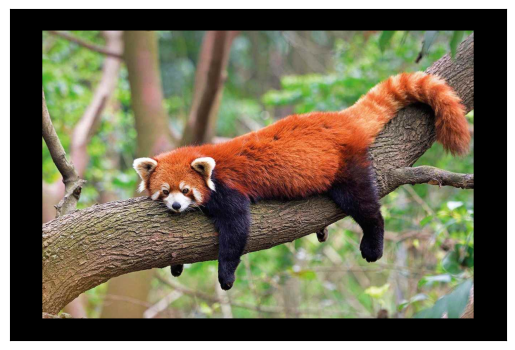

In [19]:
print("ORIGINAL PANDA", panda.max(), panda.min(), panda.shape)
print("FRAME", frame.max(), frame.min(), frame.shape)    
plt.imshow(frame, vmin=0, vmax=255)
plt.xticks([]); plt.yticks([]) # Off ticks
plt.show()

b) Change the frame of the new image to green. Visualize the three images: original, black frame and green frame, in one single figure, with their respective titles.

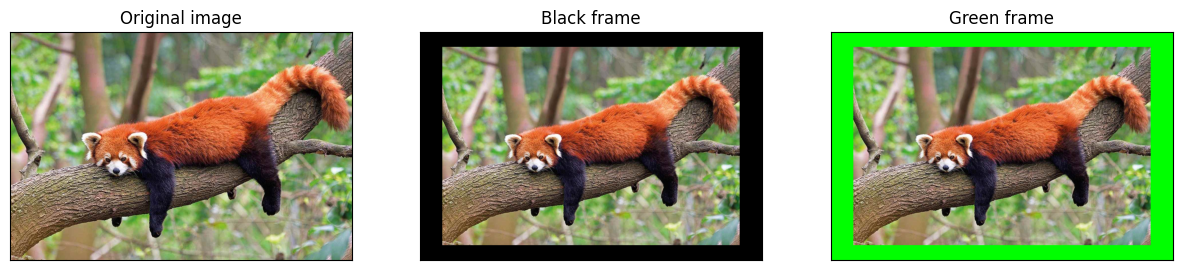

In [20]:
ig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15,5))

# Frame setup
factor = 1.15
frame = np.zeros((100,100,3), dtype=np.uint8)
frame = resize(frame, (panda.shape[0]*factor, panda.shape[1]*factor), anti_aliasing=True)
frame = img_as_ubyte(frame)

ax = axs[0]
ax.imshow(panda)
ax.set_title('Original image')

ax = axs[1]
black_frame = np.copy(frame)
embed(black_frame, panda)
ax.imshow(black_frame)
ax.set_title('Black frame')

ax = axs[2]
green_frame = np.copy(frame)
green_frame[:,:,1] = 255
embed(green_frame, panda)
ax.imshow(green_frame)
ax.set_title('Green frame')

plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()

### 1.5 Contrast enhancement

a) In some domains like medical imaging, it is common to have images with low contrast. Open the image `images_notebook/cell_lowcontrast.jpg` and visualize it without graylevel enhancement. Print the image size, data type, minimum and maximum of the image.

**Note:** When running the function `imshow()` the image is authomatically enhanced. Use the `vmin` and `vmax` parameters in order to deactivate the enhancement applied by default. To this purpose, check the data type and used the maximum and minimum value corresponding to this type.


uint8 80 255


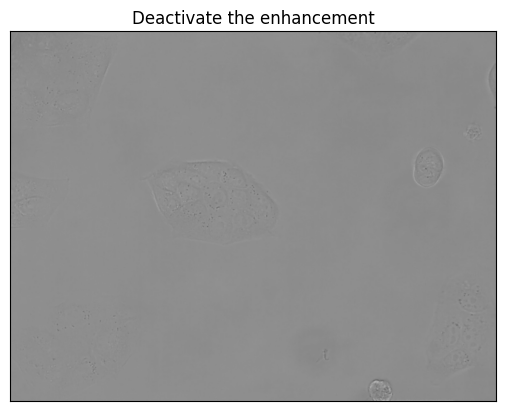

In [21]:
cell = io.imread("images_notebook/cell_lowcontrast.png")
print(cell.dtype, cell.min(), cell.max())
plt.imshow(cell, vmin=cell.min(), vmax=cell.max())
plt.xticks([]); plt.yticks([]) # Off ticks
plt.title("Deactivate the enhancement")
plt.show()

b) Create an image called `dark_image` using the  values from the original one. Compute the minimum value of the image and substract this value of the original image. Print the new maximum a minimum values. Show the new image without graylevel enhancement.

uint8 0 175


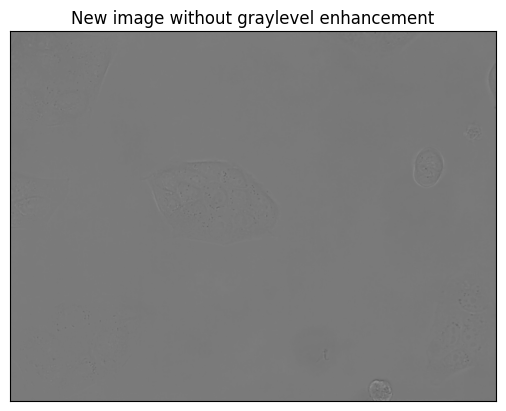

In [22]:
dark_image = cell - cell.min()
print(dark_image.dtype, dark_image.min(), dark_image.max())
plt.imshow(dark_image, vmin=dark_image.min(), vmax=dark_image.max())
plt.xticks([]); plt.yticks([]) # Off ticks
plt.title("New image without graylevel enhancement")
plt.show()

c) Similarly to the previous question, create a new image called `bright_im` from the original one, so that the maximal value of the new image is 255. Check the minimal and maximal values of the new image, and show the new image without graylevel enhancement.


uint8 80 255


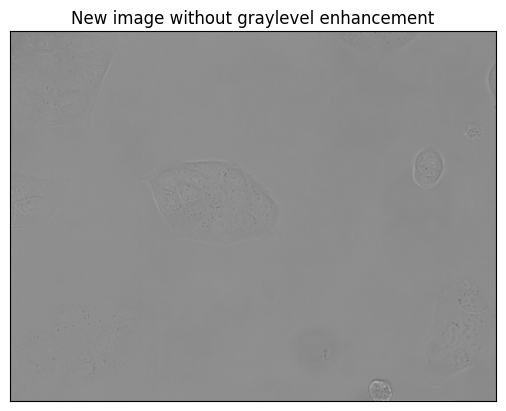

In [46]:
# Original one already has maximal value of 255...
bright_image = cell
print(bright_image.dtype, bright_image.min(), bright_image.max())
plt.imshow(bright_image, vmin=bright_image.min(), vmax=bright_image.max())
plt.xticks([]); plt.yticks([]) # Off ticks
plt.title("New image without graylevel enhancement")
plt.show()

d) Apply contrast enhancement to the original image. There are two ways for it: (1) by direct manipulation, and (2) through scikit-image command [rescale_intensity](https://scikit-image.org/docs/stable/api/skimage.exposure.html#skimage.exposure.rescale_intensity). Check the minimal and maximal values of the enhanced image, and compare them with the previous one. Show the two images  without graylevel enhancement.

In [24]:
from skimage.exposure import rescale_intensity
help(rescale_intensity)

Help on function rescale_intensity in module skimage.exposure.exposure:

rescale_intensity(image, in_range='image', out_range='dtype')
    Return image after stretching or shrinking its intensity levels.

    The desired intensity range of the input and output, `in_range` and
    `out_range` respectively, are used to stretch or shrink the intensity range
    of the input image. See examples below.

    Parameters
    ----------
    image : array
        Image array.
    in_range, out_range : str or 2-tuple, optional
        Min and max intensity values of input and output image.
        The possible values for this parameter are enumerated below.

        'image'
            Use image min/max as the intensity range.
        'dtype'
            Use min/max of the image's dtype as the intensity range.
        dtype-name
            Use intensity range based on desired `dtype`. Must be valid key
            in `DTYPE_RANGE`.
        2-tuple
            Use `range_values` as explicit min/m

ENHANCED uint8 0 255


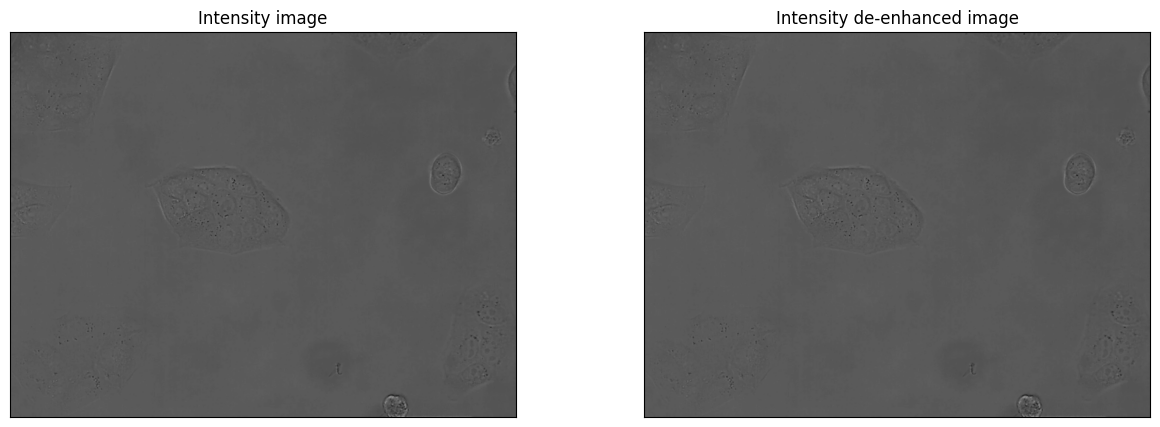

In [44]:
# Downscale
intensity = rescale_intensity(cell, in_range='image', out_range=(0, 255)).astype(np.uint8)
print("ENHANCED", intensity.dtype, intensity.min(), intensity.max())

ig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15,5))

ax = axs[0]
ax.imshow(intensity)
ax.set_title('Intensity image')

ax = axs[1]
ax.imshow(intensity, vmin=intensity.min(), vmax=intensity.max())
ax.set_title('Intensity de-enhanced image')

plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()

e) Visualize the 5 images in the same figure, each one with its corresponding title.

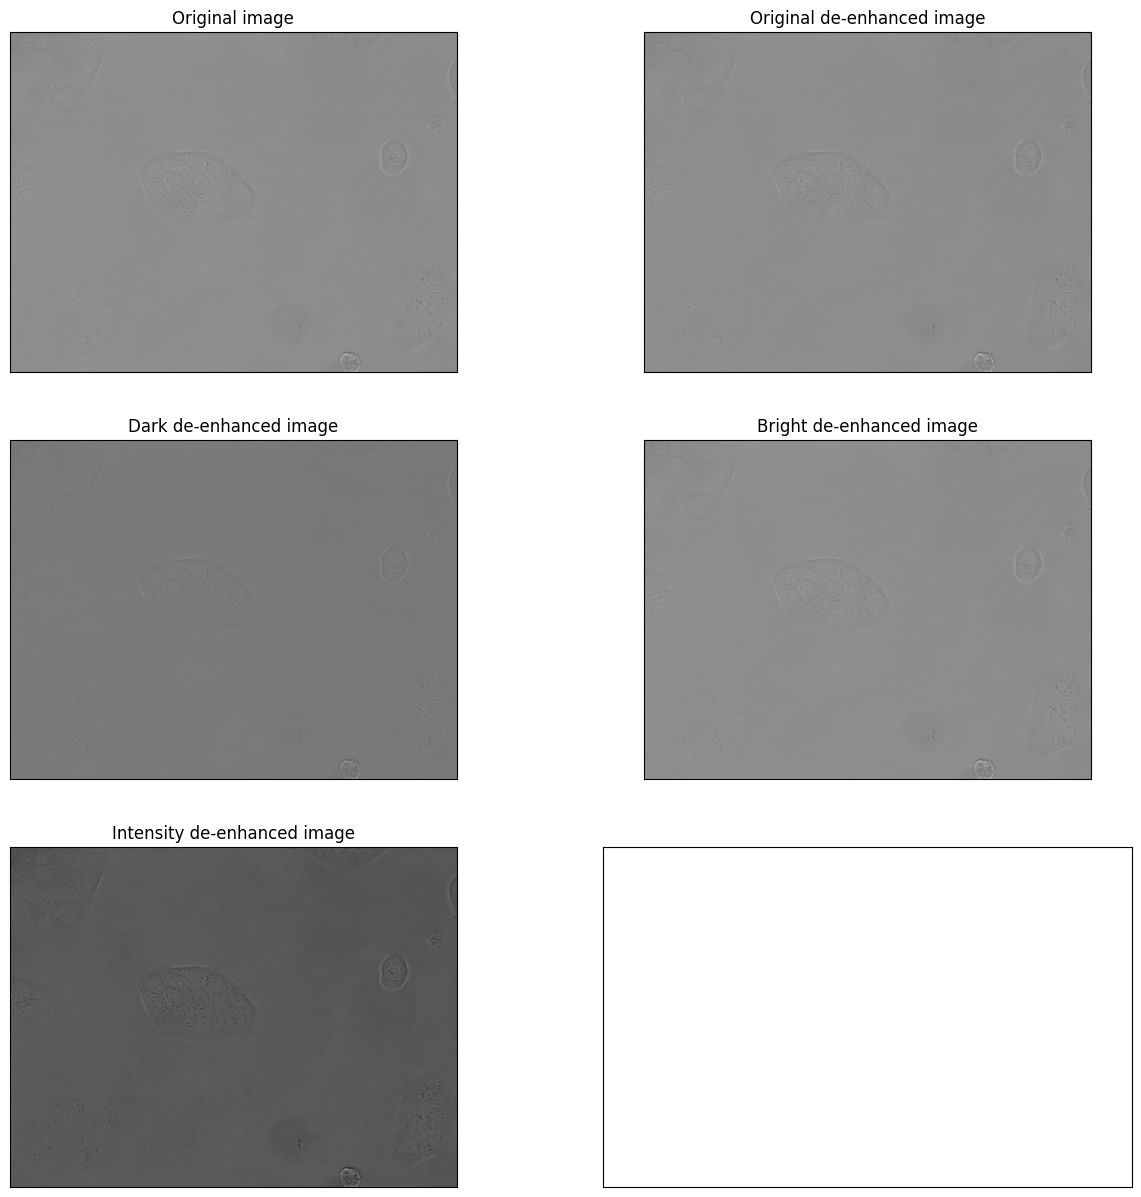

In [26]:
ig, axs = plt.subplots(nrows=3, ncols=2, figsize=(15,15))

ax = axs[0,0]
ax.imshow(cell)
ax.set_title('Original image')

ax = axs[0,1]
ax.imshow(cell, vmin=cell.min(), vmax=cell.max())
ax.set_title('Original de-enhanced image')

ax = axs[1,0]
ax.imshow(dark_image, vmin=dark_image.min(), vmax=dark_image.max())
ax.set_title('Dark de-enhanced image')

ax = axs[1,1]
ax.imshow(bright_image, vmin=bright_image.min(), vmax=bright_image.max())
ax.set_title('Bright de-enhanced image')

ax = axs[2,0]
ax.imshow(intensity, vmin=intensity.min(), vmax=intensity.max())
ax.set_title("Intensity de-enhanced image")

plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()

### 1.6 Color manipulation

a) Read and visualize the image `images_notebook/barcelona.jpg` (see figure top). Extract its three channels and visualize them in the same figure with their respective titles (see the figure bottom).
<img src="images_notebook/barcelona.jpg">

<img src="images_notebook/barcelona_channels.png">

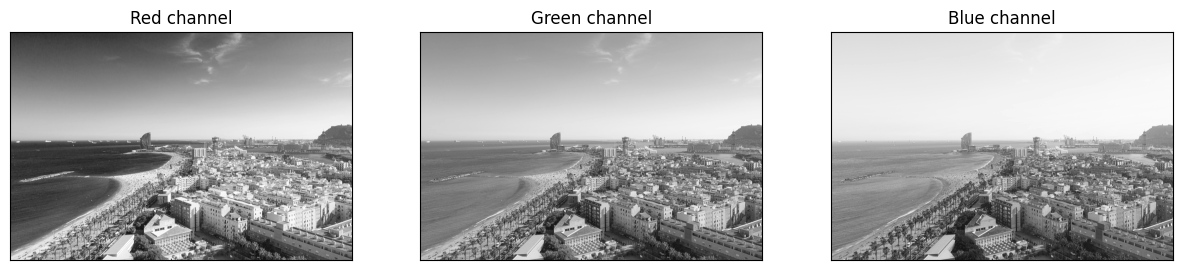

In [27]:
barcelona = io.imread("images_notebook/barcelona.jpg")
r = barcelona[:, :, 0]  # Red
g = barcelona[:, :, 1]  # Green
b = barcelona[:, :, 2]  # Blue
ig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15,5))

ax = axs[0]
ax.imshow(r, cmap="gray") # Alternatively, cmap="Reds"
ax.set_title('Red channel')

ax = axs[1]
ax.imshow(g,cmap="gray") # Alternatively, cmap="Greens"
ax.set_title("Green channel")

ax = axs[2]
ax.imshow(b,cmap="gray") # Alternatively, cmap="Blues"
ax.set_title("Blue channel")

plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()

d) Read and visualize the image images_notebook/chairs.jpg.
Interchange the red and blue channels and show the original and resulting image side by side with their respective titles.

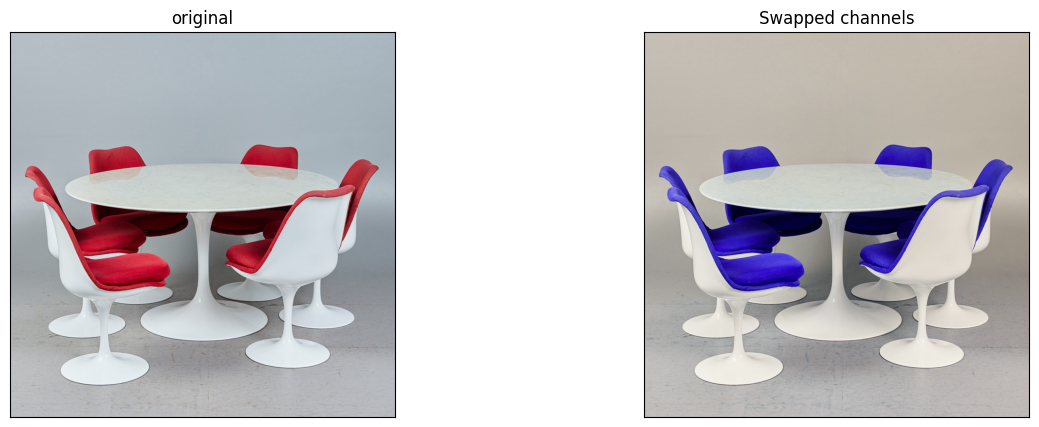

In [28]:
original_chairs = io.imread("images_notebook/chairs.jpg")
# Create a copy of the original chairs to modify
chairs = np.copy(original_chairs)
chairs[:,:,0] = original_chairs[:,:,2]
chairs[:,:,2] = original_chairs[:,:,0]

ig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15,5))

ax = axs[0]
ax.imshow(original_chairs)
ax.set_title("original")

ax = axs[1]
ax.imshow(chairs)
ax.set_title("Swapped channels")

plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()

### 1.7 Masks and logical image manipulation

a) Read the image `images_notebook/circles.bmp` (see figure top) and define 3 images in such a way that each one contains only 1 ball (see figure bottom). Visualize the 3 images in the same figure, each one with its corresponding title.

<img src="images_notebook/ex16.png">

**Note:** Be careful when applying `imshow` since it automatically increases the contrast of the image (putting minimum values to 0 and maximal to 1).

**Note:** Be careful when applying type conversion. Check the ranges of the image values.

In [29]:
help(np.logical_and)

Help on ufunc:

logical_and = <ufunc 'logical_and'>
    logical_and(x1, x2, /, out=None, *, where=True, casting='same_kind', order='K', dtype=None, subok=True[, signature])

    Compute the truth value of x1 AND x2 element-wise.

    Parameters
    ----------
    x1, x2 : array_like
        Input arrays.
        If ``x1.shape != x2.shape``, they must be broadcastable to a common
        shape (which becomes the shape of the output).
    out : ndarray, None, or tuple of ndarray and None, optional
        A location into which the result is stored. If provided, it must have
        a shape that the inputs broadcast to. If not provided or None,
        a freshly-allocated array is returned. A tuple (possible only as a
        keyword argument) must have length equal to the number of outputs.
    where : array_like, optional
        This condition is broadcast over the input. At locations where the
        condition is True, the `out` array will be set to the ufunc result.
        Elsewher

In [30]:
circles = img_as_ubyte(io.imread("images_notebook/circles.bmp"))
first_ball, second_ball, third_ball = [np.copy(circles) for _ in range(3)]

mask = first_ball > 0
first_ball[mask] = 255

mask = np.logical_and(second_ball > 0, second_ball < 150)
second_ball[~mask] = 255

mask = third_ball > 150
third_ball[~mask] = 255

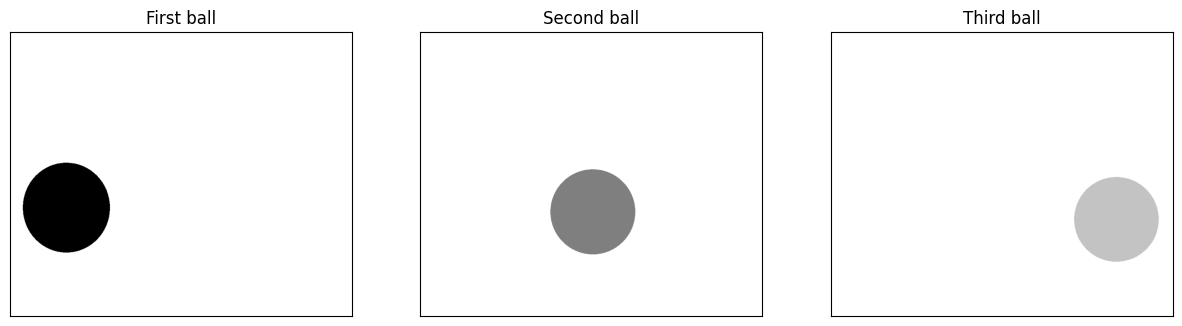

In [31]:
# To prevent this and display the pixel values as they are, 
# we need to explicitly specify the range of values using the vmin and vmax parameters.
ig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15,5))

ax = axs[0]
ax.imshow(first_ball, vmin=first_ball.min(), vmax=first_ball.max())
ax.set_title("First ball")

ax = axs[1]
ax.imshow(second_ball, vmin=second_ball.min(), vmax=second_ball.max())
ax.set_title("Second ball")

ax = axs[2]
ax.imshow(third_ball, vmin=third_ball.min(), vmax=third_ball.max())
ax.set_title("Third ball")

plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()

b) Now create a similar plot to the previous one, but this time each of the 3 images must contain two balls.
- The first image must contain the central and right balls.
- The second image must contain the left and right balls.
- The third image must contain the left and central balls.

In [32]:
# First and third cases are very similar to last ones
# We just have to use unary operator ~ to negate the mask
cr_balls, lr_balls, lc_balls = [np.copy(circles) for _ in range(3)]

mask = cr_balls > 0
cr_balls[~mask] = 255

mask = np.logical_and(lr_balls > 0, lr_balls < 150)
lr_balls[mask] = 255

mask = lc_balls > 150
lc_balls[mask] = 255

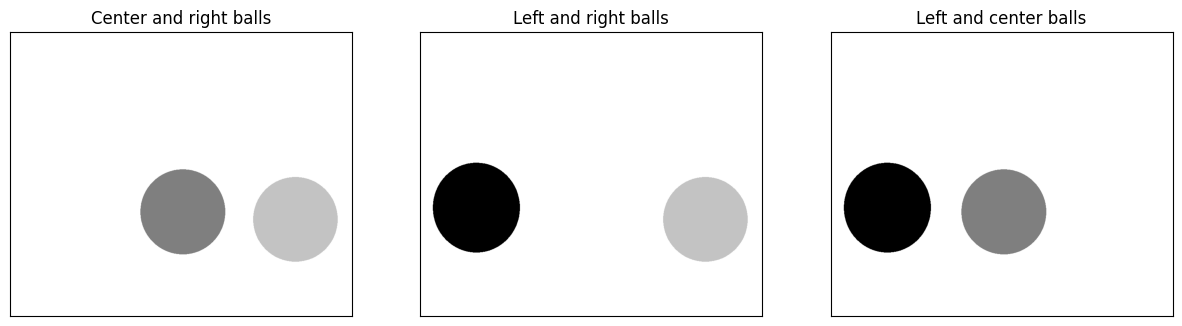

In [33]:
# To prevent this and display the pixel values as they are, 
# we need to explicitly specify the range of values using the vmin and vmax parameters.
ig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15,5))

ax = axs[0]
ax.imshow(cr_balls, vmin=cr_balls.min(), vmax=cr_balls.max())
ax.set_title("Center and right balls")

ax = axs[1]
ax.imshow(lr_balls, vmin=lr_balls.min(), vmax=lr_balls.max())
ax.set_title("Left and right balls")

ax = axs[2]
ax.imshow(lc_balls, vmin=lc_balls.min(), vmax=lc_balls.max())
ax.set_title("Left and center balls")

plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()

c) Given the images `images_notebook/coat.png` and `images_notebook/model.png` (first two images on the figure below), implement the necessary code to construct the image of the model with the coat (third image). Next find in internet an image with a texture and apply it to obtain an image of the jacket with the found texture (fourth image is only an example).

<img src="images_notebook/ex17d.png">

**Note:** when applying [resize, rotate, etc...](https://scikit-image.org/docs/stable/auto_examples/transform/plot_rescale.html) keep track how the image type and values range change. When necessary, apply type conversion using [img_as_float, img_as_uint, img_as_ubyte.](https://scikit-image.org/docs/stable/api/skimage.html)

**Note: DO NOT USE LOOPS to overlap the images!! It will be penalized.**


In [34]:
from skimage.color import rgba2rgb
coat = img_as_ubyte(rgba2rgb(io.imread("images_notebook/coat.png")))   # RGB
model = img_as_ubyte(rgba2rgb(io.imread("images_notebook/model.png"))) # RGB

In [35]:
def blend(model, coat):
    
    final_image = model.copy()

    # Step 1: Resize the coat to match the dimensions of the model (if needed)
    if coat.shape != model.shape:
        coat = resize(coat, model.shape, anti_aliasing=True)
    
    # Step 2: Create a mask for non-black pixels
    # A pixel is considered non-black if its grayscale value is greater than 0
    mask = coat > 0        # Mask for non-black pixels
    coat = coat * mask     # Apply mask to coat
    model = model * ~mask  # Put all pixels corresponding to the coat to black in model
    
    # Step 3: Combine the masked coat with the model (wherever coat is not black)
    final_image = model + coat
    
    return final_image

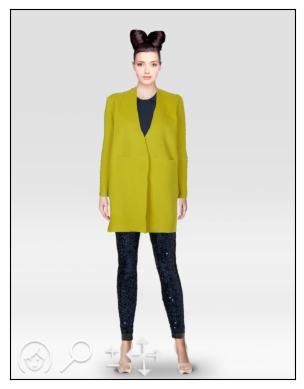

In [36]:
yellow_coat = img_as_ubyte(blend(model, coat))

plt.imshow(yellow_coat, vmin=0, vmax=255)
plt.xticks([]); plt.yticks([]) # Off ticks
plt.show()

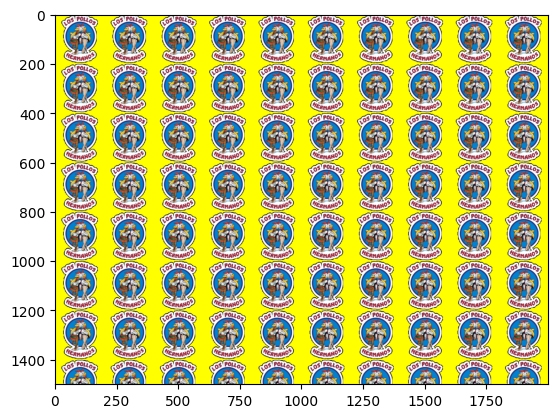

In [37]:
# Note:
# We wanted to create a cool pattern as an extra activity.
# As a disclaimer, we used AI (ChatGPT) to do so.

def create_pattern(logo_path, img_size, tile_size, output_path):
    # Step 1: Load the Los Pollos Hermanos logo image
    logo = io.imread(logo_path)

    # Step 2: Resize the logo to the tile size using skimage.transform.resize
    logo = resize(logo, tile_size, anti_aliasing=True)

    # Step 3: Create a blank tablecloth with the specified size (black background)
    tablecloth = np.ones((tablecloth_size[1], tablecloth_size[0], 4), dtype=np.float32)
    tablecloth[:, :, 0] = 1  # Red channel
    tablecloth[:, :, 1] = 1  # Green channel
    tablecloth[:, :, 2] = 0  # Blue channel (so it's yellow)
    tablecloth[:, :, 3] = 1  # Alpha channel fully opaque

    mask = rgb2gray(logo[:, :, :3]) > 0 # Ignore the alpha channel for the logo
    
    # Apply the mask to the coat's alpha channel (black background should be transparent)
    logo[:, :, 3] = mask.astype(float)  # Set alpha to 1 where mask is True, 0 where False
    
    # Step 4: Tile the logo across the tablecloth
    for y in range(0, tablecloth_size[1], tile_size[1]):
        for x in range(0, tablecloth_size[0], tile_size[0]):
            tablecloth[y:y+tile_size[1], x:x+tile_size[0], :] = blend(tablecloth[y:y+tile_size[1], x:x+tile_size[0], :],
                  logo[:min(tile_size[1], tablecloth_size[1]-y), :min(tile_size[0], tablecloth_size[0]-x), :])
            
    # Step 5: Convert the image to uint8 format and show
    tablecloth_uint8 = img_as_ubyte(tablecloth)
    plt.imshow(img_as_ubyte(tablecloth_uint8), vmin=tablecloth_uint8.min(), vmax=tablecloth_uint8.max())
    
    # Step 6: Save the final pattern
    io.imsave(output_path, tablecloth_uint8)

# Parameters for the tablecloth pattern
logo_path = "images_notebook/lospollos.png"  # Path to the logo file
tablecloth_size = (2000, 1500)  # Size of the tablecloth (e.g., 2000x1500 pixels)
tile_size = (200, 200)  # Size of each tile (logo size)
output_path = "images_notebook/pattern.png"  # Output file

# Create the tablecloth pattern
create_pattern(logo_path, tablecloth_size, tile_size, output_path)

In [38]:
# Now a new coat should be generated, and blended as in last step
# Very similar to blend() function
def texture_coat(coat, texture):
    
    final_image = model.copy()

    # Step 1: Resize the coat to match the dimensions of the model (if needed)
    if coat.shape != texture.shape:
        texture = resize(texture, coat.shape, anti_aliasing=True)
    
    # Step 2: Create a mask for non-black pixels
    # A pixel is considered non-black if its grayscale value is greater than 0
    mask = coat > 0  # Mask for non-black pixels
    coat = texture * mask
    
    return coat

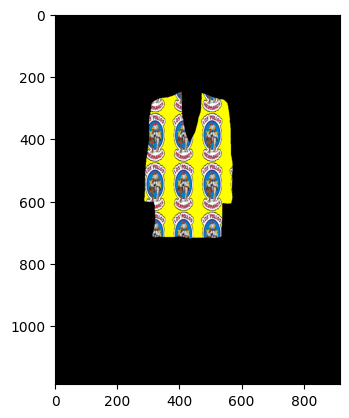

In [39]:
# Load the coat and model image again, because are modified in blend
coat = img_as_ubyte(rgba2rgb(io.imread("images_notebook/coat.png")))   # RGB
model = img_as_ubyte(rgba2rgb(io.imread("images_notebook/model.png"))) # RGB
texture = img_as_float(rgba2rgb(io.imread("images_notebook/pattern.png"))) # RGB

txtrzd_coat = img_as_ubyte(texture_coat(coat, texture))
plt.imshow(txtrzd_coat, vmin=txtrzd_coat.min(), vmax=txtrzd_coat.max())
last_model = blend(model, txtrzd_coat)

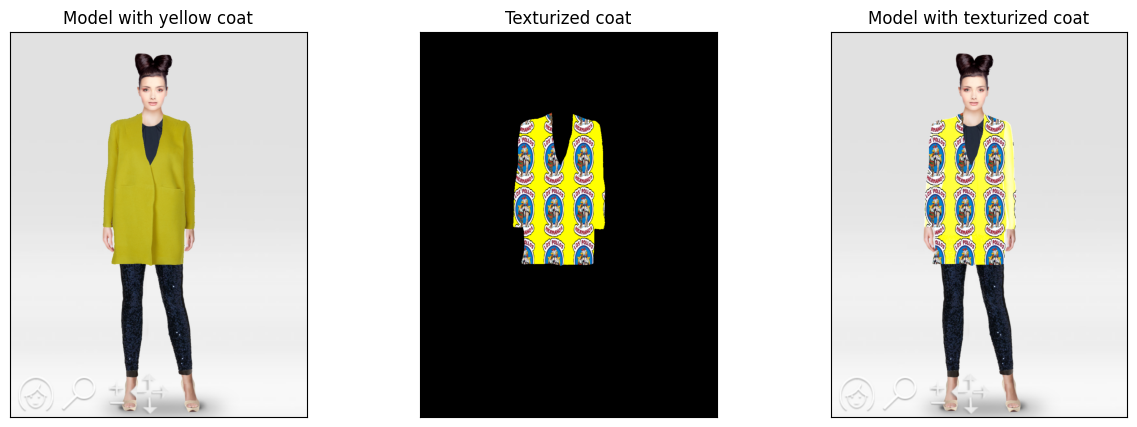

In [40]:
# To prevent this and display the pixel values as they are, 
# we need to explicitly specify the range of values using the vmin and vmax parameters.
ig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15,5))

ax = axs[0]
ax.imshow(yellow_coat, vmin=yellow_coat.min(), vmax=yellow_coat.max())
ax.set_title("Model with yellow coat")

ax = axs[1]
uint_txtrzd_coat = img_as_ubyte(txtrzd_coat)
ax.imshow(uint_txtrzd_coat, vmin=uint_txtrzd_coat.min(), vmax=uint_txtrzd_coat.max())
ax.set_title("Texturized coat")

ax = axs[2]

ax.imshow(last_model, vmin=last_model.min(), vmax=last_model.max())
ax.set_title("Model with texturized coat")

plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()